Please use pythoon version 3.12

In [1]:
!python --version
%pip install -q recbole pandas numpy openpyxl kmeans-pytorch
%pip install -q "ray[tune]"
%pip install -U -q ipywidgets

Python 3.12.10
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import pathlib for platform-independent file and directory handling.
from pathlib import Path

# Import numerical, tabular, plotting, sparse matrix, and tensor libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch

# Import RecBole utilities for loading saved models and rebuilding dataset
# objects and dataloaders where required.
from recbole.quick_start import load_data_and_model
import torch
from recbole.data import create_dataset, data_preparation
from recbole.utils import init_seed, init_logger, get_model

# Set a PyTorch environment flag to avoid weights-only loading behaviour that
# may interfere with the current model-loading workflow.
import os

os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

# Configure default plotting behaviour for figure size and grid display.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

# Resolve the current working directory as the project root.
PROJECT_ROOT = Path.cwd()

# Define key input paths for the trained model, prepared training split, and
# raw event data.
MODEL_PATH = (
    PROJECT_ROOT
    / "output"
    / "retailrocket_itemknn"
    / "saved_models"
    / "ItemKNN-Apr-15-2026_14-17-45.pth"
)
TRAIN_SPLIT_PATH = (
    PROJECT_ROOT
    / "output"
    / "retailrocket_itemknn_chronological"
    / "prepared_splits"
    / "train_interactions.csv"
)
EVENTS_PATH = PROJECT_ROOT / "input" / "events.csv"

# Define output directories for generated tables and figures.
TABLE_DIR = PROJECT_ROOT / "output" / "retailrocket_itemknn" / "tables"
FIG_DIR = PROJECT_ROOT / "output" / "retailrocket_itemknn" / "figures"

# Create the output directories if they do not already exist.
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Fail early if any required input artefact is missing.
assert MODEL_PATH.exists(), f"Missing model file: {MODEL_PATH}"
assert TRAIN_SPLIT_PATH.exists(), f"Missing train split: {TRAIN_SPLIT_PATH}"
assert EVENTS_PATH.exists(), f"Missing events file: {EVENTS_PATH}"

# Print the main resolved paths for verification.
print("Project root:", PROJECT_ROOT)
print("Model path:", MODEL_PATH)
print("Train split path:", TRAIN_SPLIT_PATH)
print("Events path:", EVENTS_PATH)

Project root: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project
Model path: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn\saved_models\ItemKNN-Apr-15-2026_14-17-45.pth
Train split path: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn_chronological\prepared_splits\train_interactions.csv
Events path: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\input\events.csv


## Load the trained ItemKNN model

In [ ]:
# Define the directory containing the saved RecBole artefacts.
SAVED_DIR = PROJECT_ROOT / "output" / "retailrocket_itemknn" / "saved_models"

# Define explicit paths for the saved dataset, dataloaders, and trained model
# checkpoint.
DATASET_PTH = SAVED_DIR / "retailrocket_itemknn_chrono-Dataset.pth"
DATALOADER_PTH = SAVED_DIR / "retailrocket_itemknn_chrono-for-ItemKNN-dataloader.pth"
MODEL_PTH = SAVED_DIR / "ItemKNN-Apr-15-2026_14-17-45.pth"

# Fail early if any required artefact is missing.
assert MODEL_PTH.exists(), f"Missing model checkpoint: {MODEL_PTH}"
assert DATASET_PTH.exists(), f"Missing saved dataset: {DATASET_PTH}"
assert DATALOADER_PTH.exists(), f"Missing saved dataloaders: {DATALOADER_PTH}"


def load_saved_recbole_artifacts(model_file, dataset_file, dataloaders_file):
    """
    Load a trained RecBole model together with its saved dataset and dataloaders.

    The checkpoint configuration is patched to use local paths for the saved
    dataset and dataloader artefacts. Inference is forced onto CPU so the
    notebook can run without GPU requirements.

    Args:
        model_file: Path to the saved RecBole model checkpoint.
        dataset_file: Path to the saved RecBole dataset artefact.
        dataloaders_file: Path to the saved RecBole dataloader artefact.

    Returns:
        A tuple containing the patched configuration, restored model, dataset,
        training dataloader, validation dataloader, and test dataloader.
    """
    # Load the full checkpoint, including configuration and trained weights.
    checkpoint = torch.load(
        model_file,
        weights_only=False,
        map_location="cpu",
    )

    # Extract the saved configuration from the checkpoint.
    config = checkpoint["config"]

    # Patch runtime paths so the local notebook uses the saved artefacts in the
    # current environment.
    config["checkpoint_dir"] = str(Path(model_file).parent)
    config["dataset_save_path"] = str(dataset_file)
    config["dataloaders_save_path"] = str(dataloaders_file)

    # Force CPU-based inference for notebook compatibility.
    config["use_gpu"] = False
    config["device"] = "cpu"

    # Reinitialise the RecBole runtime environment with the saved settings.
    init_seed(config["seed"], config["reproducibility"])
    init_logger(config)

    # Load the saved filtered dataset instead of recreating it from raw files.
    dataset = create_dataset(config)

    # Load the saved split dataloaders instead of rebuilding them.
    train_data, valid_data, test_data = data_preparation(config, dataset)

    # Recreate the model shell, restore learned weights, and switch to
    # evaluation mode.
    model = get_model(config["model"])(config, train_data._dataset).to("cpu")
    model.load_state_dict(checkpoint["state_dict"])
    model.load_other_parameter(checkpoint.get("other_parameter"))
    model.eval()

    return config, model, dataset, train_data, valid_data, test_data


# Load the saved configuration, model, dataset, and split dataloaders.
config, model, dataset, train_data, valid_data, test_data = (
    load_saved_recbole_artifacts(
        str(MODEL_PTH),
        str(DATASET_PTH),
        str(DATALOADER_PTH),
    )
)

# Extract the learned item-item similarity matrix.
item_similarity = model.w.tocsc()

# Extract the full prediction matrix produced by the trained ItemKNN model.
pred_matrix = model.pred_mat.tocsr()

# Extract the sparse user-item interaction matrix used for training.
train_matrix = model.interaction_matrix.tocsr()

# Create a binary version of the training matrix for analyses that require only
# interaction presence rather than weighted values.
binary_train_matrix = train_matrix.copy().astype(np.float32)
binary_train_matrix.data = np.ones_like(
    binary_train_matrix.data,
    dtype=np.float32,
)

# Print key metadata about the restored model and artefacts.
print("Model:", config["model"])
print("Dataset:", config["dataset"])
print("checkpoint_dir:", config["checkpoint_dir"])
print("dataset_save_path:", config["dataset_save_path"])
print("dataloaders_save_path:", config["dataloaders_save_path"])
print("Train matrix shape:", train_matrix.shape)
print("Non-zero training interactions:", train_matrix.nnz)

16 Apr 10:53    INFO  Load filtered dataset from: [e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn\saved_models\retailrocket_itemknn_chrono-Dataset.pth]
16 Apr 10:54    INFO  Load split dataloaders from: [e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn\saved_models\retailrocket_itemknn_chrono-for-ItemKNN-dataloader.pth]
c:\Users\pippa\AppData\Local\Programs\Python\Python312\Lib\site-packages\recbole\data\dataset\dataset.py:2136: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)

Model: ItemKNN
Dataset: retailrocket_itemknn_chrono
checkpoint_dir: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn\saved_models
dataset_save_path: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn\saved_models\retailrocket_itemknn_chrono-Dataset.pth
dataloaders_save_path: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn\saved_models\retailrocket_itemknn_chrono-for-ItemKNN-dataloader.pth
Train matrix shape: (1407581, 220009)
Non-zero training interactions: 1743817


## Load the chronological training split and choose a demo user/item

In [ ]:
# Load the prepared training split used for the demo workflow.
train_split = pd.read_csv(TRAIN_SPLIT_PATH)

# Define the expected user, item, and optional timestamp column names.
USER_COL = "user_id"
ITEM_COL = "item_id"
TIME_COL = "timestamp" if "timestamp" in train_split.columns else None

# Validate that the required user and item identifier columns are present.
if USER_COL not in train_split.columns or ITEM_COL not in train_split.columns:
    raise ValueError(f"Expected columns '{USER_COL}' and '{ITEM_COL}' in {TRAIN_SPLIT_PATH}")

# Convert identifiers to string format for consistency with RecBole tokens.
train_split[USER_COL] = train_split[USER_COL].astype(str)
train_split[ITEM_COL] = train_split[ITEM_COL].astype(str)

# Optional manual overrides for the demo user and anchor item selection.
DEMO_USER_TOKEN = None
ANCHOR_ITEM_TOKEN = None
MIN_HISTORY_ITEMS = 5

# Count the number of distinct interacted items per user and rank users by
# interaction breadth.
user_history_counts = (
    train_split.groupby(USER_COL)[ITEM_COL]
    .nunique()
    .sort_values(ascending=False)
)

# Keep only users with at least the minimum number of distinct history items.
eligible_users = user_history_counts[user_history_counts >= MIN_HISTORY_ITEMS]

# Select the demo user. Prefer an eligible user with richer history unless a
# manual override is provided.
demo_user_token = (
    str(DEMO_USER_TOKEN)
    if DEMO_USER_TOKEN is not None
    else str(eligible_users.index[0] if len(eligible_users) else user_history_counts.index[0])
)

# Extract the selected user's interaction history.
demo_user_rows = train_split[train_split[USER_COL] == demo_user_token].copy()

# Sort the selected user's history chronologically when timestamp data is
# available.
if TIME_COL is not None:
    demo_user_rows = demo_user_rows.sort_values(TIME_COL)

# Select an anchor item from the user's history.
# By default, use the user's most globally popular interacted item to make the
# neighbour demonstration easier to interpret.
if ANCHOR_ITEM_TOKEN is None:
    user_items = demo_user_rows[ITEM_COL].drop_duplicates().tolist()
    user_item_popularity = train_split[train_split[ITEM_COL].isin(user_items)][ITEM_COL].value_counts()
    demo_anchor_item_token = str(user_item_popularity.index[0])
else:
    demo_anchor_item_token = str(ANCHOR_ITEM_TOKEN)

# Convert the external user and item tokens to internal dataset identifiers.
demo_user_id = int(dataset.token2id(dataset.uid_field, [demo_user_token])[0])
demo_anchor_item_id = int(dataset.token2id(dataset.iid_field, [demo_anchor_item_token])[0])

# Print the selected demo entities in both external-token and internal-id form.
print("Demo user token:", demo_user_token)
print("Demo user internal id:", demo_user_id)
print("Anchor item token:", demo_anchor_item_token)
print("Anchor item internal id:", demo_anchor_item_id)

# Preview the selected user's interaction history.
display(demo_user_rows.head(10))

Demo user token: 1150086
Demo user internal id: 1150087
Anchor item token: 461686
Anchor item internal id: 1129


,user_id,item_id,rating,timestamp
1429836,1150086,458130,9.0,1434.0
1429835,1150086,458046,1.0,1434.0
1429832,1150086,457522,1.0,1434.0
1427186,1150086,6888,1.0,1434.0
1429891,1150086,466319,2.0,1434.0
1429892,1150086,466614,2.0,1434.0
1427153,1150086,743,1.0,1434.0
1428137,1150086,171785,1.0,1434.0
1428158,1150086,174529,1.0,1434.0
1428153,1150086,173365,2.0,1434.0


## Helper functions

In [ ]:
def ids_to_tokens(field, ids):
    """
    Convert internal RecBole identifiers to external string tokens.

    Args:
        field: Dataset field name used for token lookup.
        ids: One or more internal numeric identifiers.

    Returns:
        A NumPy array of string tokens corresponding to the supplied IDs.
    """
    # Convert inputs to a one-dimensional integer NumPy array.
    ids = np.asarray(ids, dtype=np.int64)
    ids = np.atleast_1d(ids)

    # Map internal IDs back to external dataset tokens.
    return np.asarray(dataset.id2token(field, ids)).astype(str)


def item_ids_to_tokens(ids):
    """
    Convert internal item identifiers to item tokens.

    Args:
        ids: One or more internal item identifiers.

    Returns:
        A NumPy array of item tokens.
    """
    return ids_to_tokens(dataset.iid_field, ids)


def user_ids_to_tokens(ids):
    """
    Convert internal user identifiers to user tokens.

    Args:
        ids: One or more internal user identifiers.

    Returns:
        A NumPy array of user tokens.
    """
    return ids_to_tokens(dataset.uid_field, ids)


def get_seen_item_ids(user_id):
    """
    Return item IDs already seen by a given user in training.

    Args:
        user_id: Internal user identifier.

    Returns:
        A NumPy array of internal item IDs present in the user's training row.
    """
    return train_matrix.getrow(user_id).indices.astype(int)


def get_item_to_item_recommendations(anchor_item_id, topn=10):
    """
    Retrieve the top similar items for a given anchor item.

    Similar items are ranked primarily by learned similarity weight and then by
    co-user count to improve interpretability.

    Args:
        anchor_item_id: Internal identifier of the anchor item.
        topn: Number of similar items to return.

    Returns:
        A DataFrame containing neighbour item identifiers, tokens, similarity
        scores, and supporting frequency statistics.
    """
    # Extract the sparse similarity row for the anchor item.
    row = item_similarity.getrow(anchor_item_id).tocoo()

    # Build an initial neighbour table from the sparse similarity values.
    df = pd.DataFrame(
        {
            "neighbor_item_id": row.col.astype(int),
            "similarity": row.data.astype(float),
        }
    )

    # Remove the anchor item itself and the padding item.
    df = df[
        (df["neighbor_item_id"] != anchor_item_id)
        & (df["neighbor_item_id"] != 0)
    ].copy()

    if df.empty:
        return df

    # Collect neighbour item identifiers for batch statistics.
    neighbor_ids = df["neighbor_item_id"].to_numpy()

    # Count users who interacted with both the anchor item and each neighbour.
    co_user_counts = (
        (
            binary_train_matrix[:, anchor_item_id].T
            @ binary_train_matrix[:, neighbor_ids]
        )
        .toarray()
        .ravel()
        .astype(int)
    )

    # Count users who interacted with each neighbour item.
    neighbor_user_counts = (
        np.asarray(binary_train_matrix[:, neighbor_ids].sum(axis=0))
        .ravel()
        .astype(int)
    )

    # Count users who interacted with the anchor item.
    anchor_user_count = int(
        np.asarray(binary_train_matrix[:, anchor_item_id].sum()).ravel()[0]
    )

    # Add token-level identifiers and supporting count statistics.
    df["anchor_item_token"] = item_ids_to_tokens([anchor_item_id])[0]
    df["neighbor_item_token"] = item_ids_to_tokens(neighbor_ids)
    df["co_user_count"] = co_user_counts
    df["neighbor_user_count"] = neighbor_user_counts
    df["anchor_user_count"] = anchor_user_count

    # Rank neighbours by similarity, then by shared-user count.
    df = (
        df.sort_values(
            ["similarity", "co_user_count"],
            ascending=[False, False],
        )
        .head(topn)
        .reset_index(drop=True)
    )

    return df


def get_top_user_recommendations(user_id, topn=10, exclude_seen=True):
    """
    Generate top-ranked recommendations for a given user.

    Args:
        user_id: Internal user identifier.
        topn: Number of recommendations to return.
        exclude_seen: Whether previously seen training items should be removed
            from the ranking.

    Returns:
        A DataFrame containing ranked recommended item IDs, tokens, and scores.
    """
    # Extract the full prediction vector for the selected user.
    scores = pred_matrix.getrow(user_id).toarray().ravel().astype(float)

    # Exclude the padding item from ranking.
    if len(scores) > 0:
        scores[0] = -np.inf

    # Optionally exclude items already observed in the training history.
    seen_ids = get_seen_item_ids(user_id)
    if exclude_seen and len(seen_ids) > 0:
        scores[seen_ids] = -np.inf

    # Select the top-ranked item IDs by descending score.
    top_item_ids = np.argsort(-scores)[:topn]

    # Build the ranked recommendation table.
    df = pd.DataFrame(
        {
            "rank": np.arange(1, len(top_item_ids) + 1),
            "recommended_item_id": top_item_ids.astype(int),
            "score": scores[top_item_ids],
        }
    )
    df["recommended_item_token"] = item_ids_to_tokens(top_item_ids)

    return df


def get_history_contributions(user_id, candidate_item_id, topn=10):
    """
    Explain a recommendation using the user's historical item contributions.

    Each historical interaction contributes according to the interaction value
    multiplied by the similarity between the history item and the candidate
    item.

    Args:
        user_id: Internal user identifier.
        candidate_item_id: Internal identifier of the candidate item.
        topn: Number of highest-contributing history items to return.

    Returns:
        A DataFrame of positive contribution rows ranked by contribution size.
        An empty DataFrame is returned when no history exists.
    """
    # Extract the user's sparse interaction history.
    user_row = train_matrix.getrow(user_id)
    history_item_ids = user_row.indices.astype(int)
    history_values = user_row.data.astype(float)

    if len(history_item_ids) == 0:
        return pd.DataFrame()

    # Retrieve similarity values between history items and the candidate item.
    sim_to_candidate = (
        item_similarity[history_item_ids, candidate_item_id]
        .toarray()
        .ravel()
        .astype(float)
    )

    # Compute contribution as interaction strength multiplied by similarity.
    contributions = history_values * sim_to_candidate

    # Build the contribution breakdown table.
    df = pd.DataFrame(
        {
            "history_item_id": history_item_ids,
            "history_item_token": item_ids_to_tokens(history_item_ids),
            "interaction_value": history_values,
            "similarity_to_candidate": sim_to_candidate,
            "contribution": contributions,
        }
    )

    # Keep only positive contributions and rank them from highest to lowest.
    df = df[df["contribution"] > 0].copy()
    df = (
        df.sort_values("contribution", ascending=False)
        .head(topn)
        .reset_index(drop=True)
    )
    return df


def get_user_event_labels(events_path, user_token, item_tokens, chunksize=300_000):
    """
    Retrieve raw event labels for selected user-item pairs from the event log.

    The event file is read in chunks to avoid loading the full dataset into
    memory. Matching event labels are merged into a slash-separated summary
    per item.

    Args:
        events_path: Path to the raw events file.
        user_token: External user token to match.
        item_tokens: Iterable of external item tokens to match.
        chunksize: Number of rows to read per chunk.

    Returns:
        A dictionary mapping item tokens to combined event-label strings.
        An empty dictionary is returned when no matching rows are found.
    """
    # Normalise item tokens to string form for consistent matching.
    item_tokens = {str(x) for x in item_tokens}
    frames = []

    # Read the event log in chunks and keep only matching user-item rows.
    for chunk in pd.read_csv(
        events_path,
        usecols=["visitorid", "itemid", "event"],
        chunksize=chunksize,
    ):
        chunk["visitorid"] = chunk["visitorid"].astype(str)
        chunk["itemid"] = chunk["itemid"].astype(str)

        matched = chunk[
            (chunk["visitorid"] == str(user_token))
            & (chunk["itemid"].isin(item_tokens))
        ]

        if not matched.empty:
            frames.append(matched)

    if not frames:
        return {}

    # Combine matching chunks and collapse event labels per item.
    df = pd.concat(frames, ignore_index=True)
    labels = (
        df.groupby("itemid")["event"]
        .apply(lambda s: " / ".join(sorted(pd.unique(s.astype(str)))))
        .to_dict()
    )
    return labels

## Show the demo user’s history

In [ ]:
# Retrieve the internal item IDs already present in the demo user's
# training history.
seen_item_ids = get_seen_item_ids(demo_user_id)

# Convert the internal history item IDs to external item tokens.
seen_item_tokens = item_ids_to_tokens(seen_item_ids)

# Build a compact preview table of the user's seen history items.
history_preview = pd.DataFrame({
    "history_item_id": seen_item_ids,
    "history_item_token": seen_item_tokens
})

# Print the number of items in the user's training history.
print(f"User {demo_user_token} has {len(seen_item_ids)} training-history items.")

# Display the first 20 history items for inspection.
display(history_preview.head(20))

User 1150086 has 2747 training-history items.


,history_item_id,history_item_token
0,10,65273
1,11,253615
2,15,222422
3,17,448220
4,37,465565
5,53,161925
6,62,38965
7,93,257575
8,110,359197
9,129,216019


## Item-to-item recommendations for one existing item

,anchor_item_token,neighbor_item_token,similarity,co_user_count,neighbor_user_count
0,461686,218794,0.292016,165,242
1,461686,171878,0.265111,132,187
2,461686,32581,0.177948,75,133
3,461686,10572,0.135463,64,168
4,461686,75392,0.096453,23,41
5,461686,108924,0.089256,20,36
6,461686,40630,0.084581,14,19
7,461686,333039,0.077301,14,23
8,461686,415928,0.075761,14,24
9,461686,250375,0.073380,16,34


16 Apr 11:16    INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
16 Apr 11:16    INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


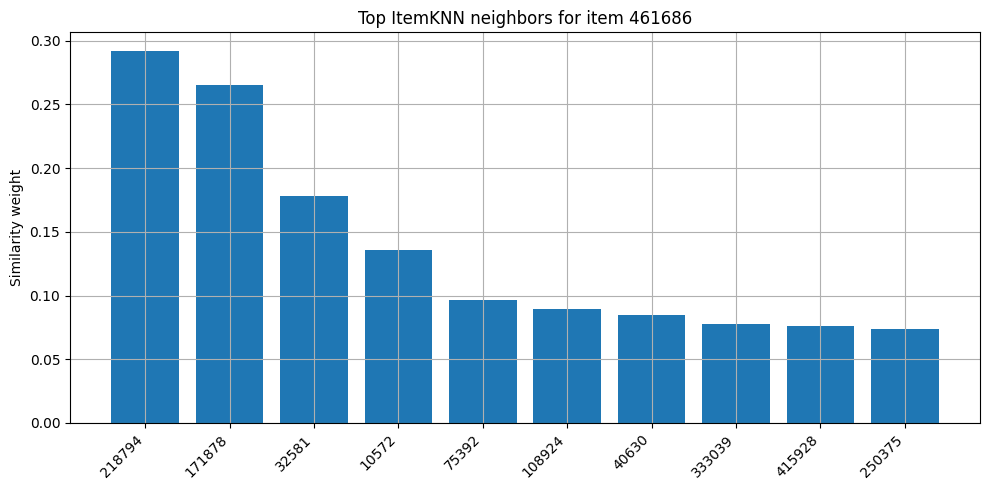

In [ ]:
# Retrieve the top similar items for the selected anchor item.
item_to_item_df = get_item_to_item_recommendations(demo_anchor_item_id, topn=10)

# Display the main neighbour-level similarity outputs for inspection.
display(
    item_to_item_df[
        [
            "anchor_item_token",
            "neighbor_item_token",
            "similarity",
            "co_user_count",
            "neighbor_user_count",
        ]
    ]
)

# Save the full item-to-item recommendation table.
item_to_item_df.to_csv(
    TABLE_DIR / "trained_itemknn_demo_item_to_item.csv",
    index=False,
)

# Plot similarity weights for the top neighbouring items.
plt.figure(figsize=(10, 5))
plt.bar(item_to_item_df["neighbor_item_token"], item_to_item_df["similarity"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Similarity weight")
plt.title(f"Top ItemKNN neighbors for item {demo_anchor_item_token}")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "trained_itemknn_demo_item_to_item_similarity.png",
    bbox_inches="tight",
)
plt.show()

## Existing-user recommendations

,rank,recommended_item_id,score,recommended_item_token
0,1,126913,12.693613,387167
1,2,102887,12.398712,32804
2,3,126902,12.319645,280720
3,4,126862,12.163706,2119
4,5,102914,11.900388,175972
5,6,102953,11.830517,362171
6,7,126919,11.431378,406780
7,8,50802,9.064626,445060
8,9,55029,8.991576,367616
9,10,72466,8.919192,460350


16 Apr 11:16    INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
16 Apr 11:16    INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


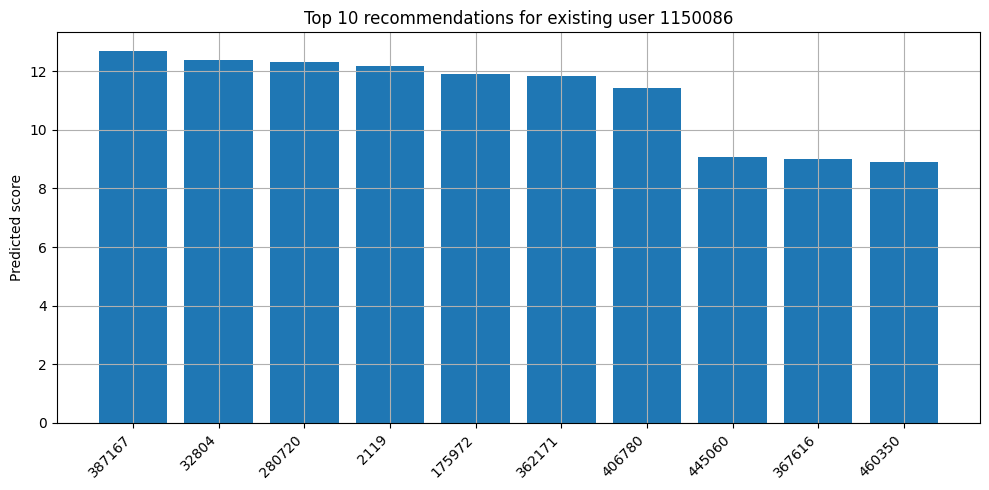

In [ ]:
# Generate the top 10 unseen recommendations for the selected demo user.
user_top10_df = get_top_user_recommendations(
    demo_user_id,
    topn=10,
    exclude_seen=True,
)

# Display the ranked recommendation table.
display(user_top10_df)

# Save the recommendation table for the existing-user demo.
user_top10_df.to_csv(
    TABLE_DIR / "trained_itemknn_demo_existing_user_top10.csv",
    index=False,
)

# Plot recommendation scores for the top 10 recommended items.
plt.figure(figsize=(10, 5))
plt.bar(user_top10_df["recommended_item_token"], user_top10_df["score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Predicted score")
plt.title(f"Top 10 recommendations for existing user {demo_user_token}")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "trained_itemknn_demo_existing_user_top10_scores.png",
    bbox_inches="tight",
)
plt.show()

## “Because you bought/viewed X” explanation for the top recommendation

,history_item_token,user_event_type,interaction_value,similarity_to_candidate,contribution
0,455240,view,1.0,0.410534,0.410534
1,348839,view,1.0,0.300754,0.300754
2,273299,view,1.0,0.256583,0.256583
3,382191,view,1.0,0.250628,0.250628
4,164820,view,1.0,0.240192,0.240192
5,45840,view,1.0,0.223000,0.223000
6,415263,view,1.0,0.223000,0.223000
7,415976,view,1.0,0.223000,0.223000
8,125904,view,1.0,0.223000,0.223000
9,182523,view,1.0,0.216388,0.216388


16 Apr 11:16    INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
16 Apr 11:16    INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


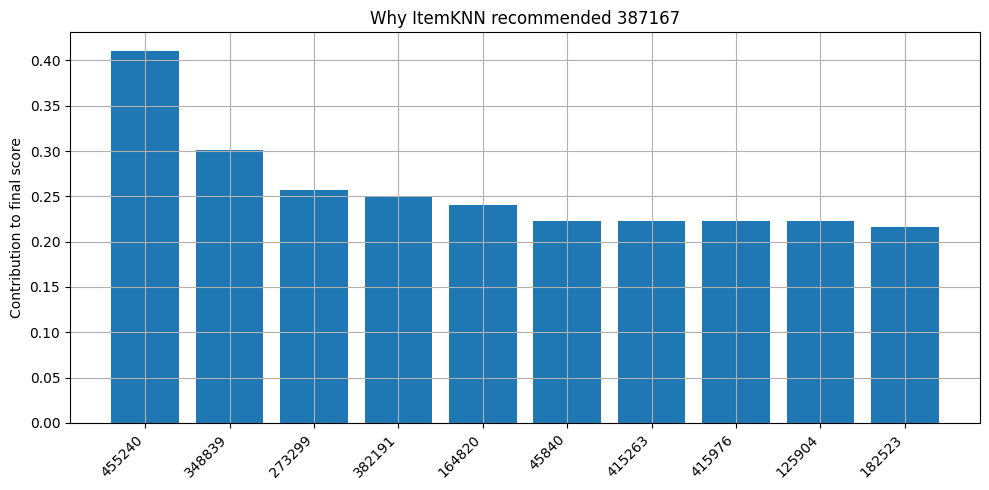

In [ ]:
# Select the top-ranked recommended item as the candidate to explain.
top_candidate_item_id = int(user_top10_df.iloc[0]["recommended_item_id"])
top_candidate_item_token = str(user_top10_df.iloc[0]["recommended_item_token"])

# Compute the highest-contributing history items behind this recommendation.
contrib_df = get_history_contributions(demo_user_id, top_candidate_item_id, topn=10)

# Retrieve raw user event labels for the contributing history items and the
# recommended candidate item from the original event log.
event_labels = get_user_event_labels(
    EVENTS_PATH,
    demo_user_token,
    item_tokens=contrib_df["history_item_token"].tolist() + [top_candidate_item_token]
)

# Attach event-label summaries to the contribution table.
contrib_df["user_event_type"] = contrib_df["history_item_token"].map(event_labels).fillna("interacted")

# Display the main explanation fields for the recommendation.
display(
    contrib_df[
        [
            "history_item_token",
            "user_event_type",
            "interaction_value",
            "similarity_to_candidate",
            "contribution",
        ]
    ]
)

# Save the recommendation-explanation table.
contrib_df.to_csv(
    TABLE_DIR / "trained_itemknn_demo_because_history_contributions.csv",
    index=False,
)

# Plot the contribution of each historical item to the recommended candidate.
plt.figure(figsize=(10, 5))
plt.bar(contrib_df["history_item_token"], contrib_df["contribution"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Contribution to final score")
plt.title(f'Why ItemKNN recommended {top_candidate_item_token}')
plt.tight_layout()
plt.savefig(
    FIG_DIR / "trained_itemknn_demo_because_you_interacted_with_x.png",
    bbox_inches="tight",
)
plt.show()

In [ ]:
# Build a short natural-language list of the strongest history-based reasons
# behind the explained recommendation.
top_reasons = []
for _, row in contrib_df.head(3).iterrows():
    top_reasons.append(f"{row['history_item_token']} ({row['user_event_type']})")

# Join the top reasons into a readable comma-separated string, or fall back to
# a generic phrase if no contribution rows are available.
reason_text = ", ".join(top_reasons) if top_reasons else "past interactions"

# Print the main entities used in the demonstration.
print(f"Anchor item for item-to-item demo: {demo_anchor_item_token}")
print(f"Top recommended item for user {demo_user_token}: {top_candidate_item_token}")
print()

# Print a concise interpretation of why the recommendation was produced.
print("Interpretation:")
print(
    f"ItemKNN recommends {top_candidate_item_token} because this user "
    f"previously interacted with {reason_text}."
)
print(
    "The contribution chart shows which past items pushed this "
    "recommendation score upward the most."
)

Anchor item for item-to-item demo: 461686
Top recommended item for user 1150086: 387167

Interpretation:
ItemKNN recommends 387167 because this user previously interacted with 455240 (view), 348839 (view), 273299 (view).
The contribution chart shows which past items pushed this recommendation score upward the most.


## # New user simulation from a basket of known item tokens 


In [ ]:
def score_new_user_from_item_history(
    history_item_tokens,
    topn=10,
    exclude_history=True,
):
    """
    Score recommendations for a pseudo-new user from item history alone.

    A sparse one-row user profile is constructed from the supplied history
    items, then multiplied by the learned item-item similarity matrix to
    obtain recommendation scores.

    Args:
        history_item_tokens: Iterable of external item tokens representing the
            pseudo-user's history.
        topn: Number of recommendations to return.
        exclude_history: Whether input history items should be excluded from
            the final ranking.

    Returns:
        A tuple containing:
            - a DataFrame of ranked recommendations
            - a list of history item tokens that were recognised by the dataset

    Raises:
        ValueError: If none of the supplied history items exist in the saved
            ItemKNN dataset.
    """
    # Keep only history items that exist in the saved dataset.
    known_tokens = []
    for tok in map(str, history_item_tokens):
        try:
            iid = int(dataset.token2id(dataset.iid_field, [tok])[0])

            # Skip padding or unknown-like zero identifiers.
            if iid != 0:
                known_tokens.append(tok)
        except Exception:
            pass

    # Stop if no valid history items can be mapped into the dataset.
    if not known_tokens:
        raise ValueError(
            "No history items were found in the saved ItemKNN dataset."
        )

    # Convert recognised item tokens to internal item identifiers.
    history_item_ids = dataset.token2id(
        dataset.iid_field,
        known_tokens,
    ).astype(int)

    # Build a 1 x n_items sparse row representing the pseudo-new user's
    # observed item history.
    row = np.zeros(len(history_item_ids), dtype=np.int32)
    data = np.ones(len(history_item_ids), dtype=np.float32)

    pseudo_user_row = sp.csr_matrix(
        (data, (row, history_item_ids)),
        shape=(1, train_matrix.shape[1]),
        dtype=np.float32,
    )

    # Score candidate items by multiplying the pseudo-user history row by the
    # learned item-item similarity matrix.
    scores = pseudo_user_row.dot(item_similarity).toarray().ravel().astype(
        float
    )

    # Exclude the padding item from ranking.
    if len(scores) > 0:
        scores[0] = -np.inf

    # Optionally exclude items already present in the input history.
    if exclude_history and len(history_item_ids) > 0:
        scores[history_item_ids] = -np.inf

    # Select the top-ranked item identifiers by descending score.
    top_item_ids = np.argsort(-scores)[:topn]

    # Build the ranked recommendation output table.
    result = pd.DataFrame(
        {
            "rank": np.arange(1, len(top_item_ids) + 1),
            "recommended_item_id": top_item_ids.astype(int),
            "score": scores[top_item_ids],
        }
    )
    result["recommended_item_token"] = item_ids_to_tokens(top_item_ids)
    result["history_item_tokens"] = ", ".join(known_tokens)

    return result, known_tokens

In [ ]:
# Define a pseudo-new user's known interaction history using item tokens that
# exist in the trained dataset.
NEW_USER_HISTORY = ["461686", "119736", "312728"]

# Score top recommendations for the pseudo-new user using only the supplied
# item-history profile.
new_user_top10_df, used_history = score_new_user_from_item_history(
    NEW_USER_HISTORY,
    topn=100,
    exclude_history=True,
)

# Print the history items that were successfully matched to the dataset.
print("Used history items:", used_history)

# Display the ranked recommendation table for the pseudo-new user.
display(new_user_top10_df)

Used history items: ['461686', '119736', '312728']


,rank,recommended_item_id,score,recommended_item_token,history_item_tokens
0,1,7271,0.330198,456056,"461686, 119736, 312728"
1,2,35602,0.309911,439963,"461686, 119736, 312728"
2,3,7492,0.292016,218794,"461686, 119736, 312728"
3,4,40430,0.289090,338395,"461686, 119736, 312728"
4,5,35590,0.286205,25762,"461686, 119736, 312728"
...,...,...,...,...,...
95,96,74105,0.121760,381055,"461686, 119736, 312728"
96,97,34126,0.121719,178799,"461686, 119736, 312728"
97,98,41716,0.121719,126143,"461686, 119736, 312728"
98,99,3070,0.121003,46232,"461686, 119736, 312728"
